<a href="https://colab.research.google.com/github/sakshimohite8/ML_Practicals_MCA/blob/main/08_SVM_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("/content/traffic.csv")

In [ ]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nColumns:")
print(df.columns)

Dataset Shape: (48204, 8)

First 5 rows:
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  Rush Hour  \
0     NaN  288.28      0.0      0.0          40       Clouds          1   
1     NaN  289.36      0.0      0.0          75       Clouds          0   
2     NaN  289.58      0.0      0.0          90       Clouds          0   
3     NaN  290.13      0.0      0.0          90       Clouds          0   
4     NaN  291.14      0.0      0.0          75       Clouds          0   

   traffic_volume  
0            5545  
1            4516  
2            4767  
3            5026  
4            4918  

Columns:
Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'Rush Hour', 'traffic_volume'],
      dtype='object')


In [ ]:
def get_level(v):
    if v < 1500: return 'low'
    elif v < 3000: return 'normal'
    elif v < 4500: return 'high'
    else: return 'heavy'

df['Traffic Situation'] = df['traffic_volume'].apply(get_level)
print(df['Traffic Situation'].value_counts())

Traffic Situation
heavy     16967
low       13372
high       9723
normal     8142
Name: count, dtype: int64


In [ ]:
print(df.corr(numeric_only=True))

                                       temp   rain_1h   snow_1h  clouds_all  \
temp                               1.000000  0.009069 -0.019755   -0.101976   
rain_1h                            0.009069  1.000000 -0.000090    0.004818   
snow_1h                           -0.019755 -0.000090  1.000000    0.027931   
clouds_all                        -0.101976  0.004818  0.027931    1.000000   
Rush Hour                          0.010211  0.007942 -0.010213    0.046262   
traffic_volume                     0.130299  0.004714  0.000733    0.067054   
holiday_Columbus Day               0.000726 -0.000076 -0.000277   -0.011738   
holiday_Independence Day           0.008272 -0.000076 -0.000277   -0.012625   
holiday_Labor Day                  0.010597  0.000046 -0.000328   -0.003201   
holiday_Martin Luther King Jr Day -0.013337 -0.000083 -0.000304    0.001898   
holiday_Memorial Day               0.007390 -0.000076 -0.000277   -0.002705   
holiday_New Years Day             -0.016973 -0.00008

In [ ]:
X = df.drop(['traffic_volume', 'Traffic Situation'], axis=1)
y = df['Traffic Situation']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (38563, 25)
Testing: (9641, 25)


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["species_encoded"] = le.fit_transform(df["species"])
print(df.head())
print(df.tail())

   sepal_length  sepal_width  petal_length  petal_width species  \
0           5.1          3.5           1.4          0.2  setosa   
1           4.9          3.0           1.4          0.2  setosa   
2           4.7          3.2           1.3          0.2  setosa   
3           4.6          3.1           1.5          0.2  setosa   
4           5.0          3.6           1.4          0.2  setosa   

   species_encoded  
0                0  
1                0  
2                0  
3                0  
4                0  
     sepal_length  sepal_width  petal_length  petal_width    species  \
145           6.7          3.0           5.2          2.3  virginica   
146           6.3          2.5           5.0          1.9  virginica   
147           6.5          3.0           5.2          2.0  virginica   
148           6.2          3.4           5.4          2.3  virginica   
149           5.9          3.0           5.1          1.8  virginica   

     species_encoded  
145            

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=12)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4389586142516336
              precision    recall  f1-score   support

       heavy       0.43      0.73      0.54      3394
        high       0.48      0.11      0.18      1945
         low       0.46      0.58      0.51      2674
      normal       0.18      0.00      0.00      1628

    accuracy                           0.44      9641
   macro avg       0.39      0.35      0.31      9641
weighted avg       0.40      0.44      0.37      9641



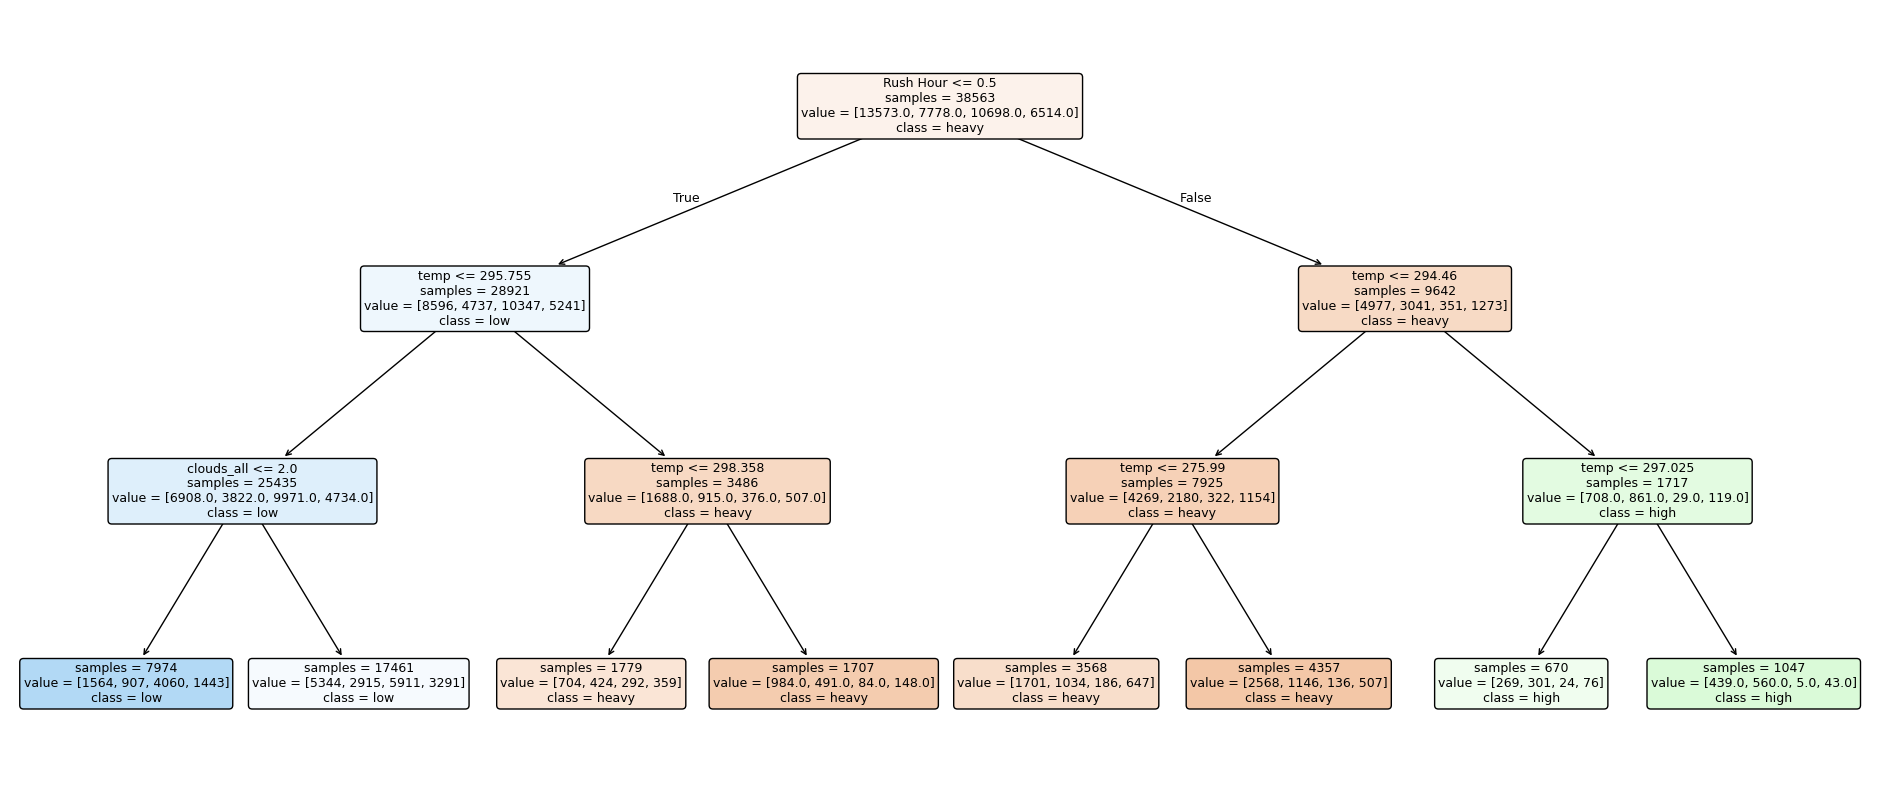

In [ ]:
plt.figure(figsize=(24, 10))
plot_tree(model, feature_names=X.columns, class_names=model.classes_, filled=True, rounded=True, fontsize=9, impurity=False)
plt.savefig("tree_final.png", dpi=300, bbox_inches='tight')
plt.show()